In [ ]:
# default_exp core.cal

In [ ]:
#hide
from nbdev.showdoc import *

In [ ]:
#export
"""
@author: yixiancao
@author: YingjieJing
"""
import os
import re
from glob import glob

import numpy as np
from matplotlib import pyplot as plt
plt.switch_backend('agg')
import scipy.interpolate as interp
import h5py
from astropy.io import fits

In [ ]:
#export
from hifast.utils.tcal import read_tcal
from hifast.utils.misc import smooth_axis1_d3, down_sample, median_filter_axis1_d3
from hifast.utils.io import save_dict_hdf5

In [ ]:
#export
class FastRawData(object):
    """ RAW data from FAST observations.
    
    Attributes
    ----------
    filename: str
        Name of Raw data file (FITS file)
    fileinfo: dict
        Infomation inferred from the filename
    obs: dict
        Basic observation informaiton from observation log (NOW hd0 header). 
    
    Methods
    ----------
    listInfo():
        Display the basic infomation about the data file.

    """
    
    
    def __init__(self, filenames, frange=None, dfactor=None, med_filter_size=None, verbose=False):
        """
        Parameters
        ----------
        filenames : list 
            FAST fits file path name
        frange : [min max], optional
            Frequency range 
        dfactor : int, optional
            downsample the spectra with "dfactor"
        med_filter_size : int, optional
            median filter spectra with size of this value
        verbose : bool, optional
            Default is False
        """
        self.filenames = filenames
        self.verbose = verbose
        if self.verbose:
            print('files:')
            for filename in self.filenames:
                print(filename)
        self.hduls = [fits.open(filename) for filename in self.filenames]
        self.hd0s = [hdul[0].header for hdul in self.hduls]
        self.hd1s = [hdul[1].header for hdul in self.hduls]
        self.lens= [header['NAXIS2'] for header in self.hd1s]
        self.inds = np.arange(np.sum(self.lens))
        
        self.frange = frange
        self.dfactor = dfactor
        self.med_filter_size = med_filter_size
        self._get_freq()
        if frange is not None:
            is_use = (self.freq<= frange[1] ) & (self.freq>= frange[0])
            self.freq_use = self.freq[is_use]
        else:
            self.freq_use= self.freq
        if self.dfactor is not None:
            self.freq_use = down_sample(self.freq_use[None,:,None], self.dfactor)[0,:,0]
        
    def get_mjds(self):
        mjds = np.hstack([hdul[1].data['UTOBS'] for hdul in self.hduls])
        return mjds
    
    def _get_freq(self, center_corr=None):
        tdata = [self.hduls[0][1].data]
        nchan = tdata[0]['NCHAN'][0]
        freq0 = tdata[0]['FREQ'][0]
        chanwidth = tdata[0]['CHAN_BW'][0]
        freq=(np.arange(nchan))*chanwidth
        freq=freq+freq0
        if center_corr is not None:
            freq += center_corr # using center frequency
        self.freq= freq
    
    def get_field(self, _inds, field='DATA', close_file=False):
        """" 
        get field with index
        """
        # if input _inds is empty, return empty
        if 0 in _inds.shape:
            if field == 'DATA':
                return np.empty(_inds.shape + (len(self.freq_use),2))
        # flat _inds
        _input_ndim = _inds.ndim
        if _input_ndim > 1:
            _in_shape= _inds.shape
            _inds= _inds.flatten()
        # make sure flattened _inds is monotone increasing
        if (np.diff(_inds)<0).any():
            raise('input index must be increasing')
        # determine the file and index of the spec in 
        lens_cum = np.hstack([0,np.cumsum(self.lens)])
        ifile =  np.searchsorted(lens_cum, _inds + 1, side='left') - 1
        ind_ifile = _inds- lens_cum[ifile]
        ifile_uni, ifile_num = np.unique(ifile, return_counts=True)
        ind_ifile_list= np.split(ind_ifile, np.cumsum(ifile_num)[:-1])
        # load data
        j_list=[]
        for j in ifile_uni:
            try:
                # test if file is opened
                self.hduls[j][1].data.shape
            except:
                self.hduls[j] = fits.open(self.filenames[j], memmap=True, lazy_load_hdus=True)
                j_list += [j,]
        if field == 'DATA':
            if self.frange is not None:
                is_use = (self.freq <= self.frange[1] ) & (self.freq >= self.frange[0]) # can't use self.freq_use
                ind_use= np.where(is_use)[0]
                # freq axis (ind_use) need use "slice" to index, coz ii is already a array; ind_use is continuous
                data = np.vstack([self.hduls[i][1].data[field][ii, ind_use[0]:ind_use[-1]+1, :2] for i, ii in zip(ifile_uni,ind_ifile_list)])
            else:
                data = np.vstack([self.hduls[i][1].data[field][ii, :, :2] for i, ii in zip(ifile_uni,ind_ifile_list)])
            #
            if self.med_filter_size is not None:
                data = median_filter_axis1_d3(data, self.med_filter_size)
            # Downsampling
            if self.dfactor is not None:
                data = down_sample(data.astype('float64'), self.dfactor)
        else:
            data = np.hstack([self.hduls[i][1].data[field][ii] for i, ii in zip(ifile_uni,ind_ifile_list)])
        #check if the length in the header is correct
        for i_tmp in ifile_uni:
            if not self.lens[i_tmp] == self.hduls[i_tmp][1].data.shape[0]:
                raise(ValueError(f"length in the header is not equal to the data shape:", self.filenames[i_tmp]))
        [self.hduls[j].close() for j in j_list]
        if close_file:
            [self.hduls[i].close() for i in ifile_uni]
        
        if _input_ndim > 1:
            return data.reshape(_in_shape + data.shape[1:])
        else:
            return data
        
    @property
    def fileinfo(self):
        fitsname = dict(value = self.filenames[0].split('/')[-1], desc = "First FITS file name")  
        dummy = fitsname['value']
        tinfo = dummy.split('-')[0]
        tinfo = tinfo.split('_') 
        #project = dict(value = 'FAST_M31', desc = "Project name")
        source = dict(value = tinfo[0], desc = "Source name")
        ipos = dict(value  = int(tinfo[1][1:]), desc = "Position number")
        #iobs = dict(value = None, desc = "Observation number")
        track_mode = dict(value = tinfo[2], desc = "Observation mode") # e.g. Tracking, drifting
        
        finfo = dummy.split('-')[1]
        finfo = finfo.split('_')
        ibeam = dict(value = int(finfo[0][1:]), desc = "Beam number") 
        #ifile = dict(value = int(finfo[-1][0:4]), desc = "File number") #ith file for the observation
        
        filetype = dict(value = 'psr' if len(finfo) < 3 else 'spec' +  finfo[1],
                         desc = "Observation type")
            
#         fileinfo = dict(fitsname = fitsname, project=project, source = source, ipos = ipos, track_mode = track_mode,
#                         iobs =iobs, ibeam = ibeam, ifile = ifile, filetype = filetype)
        fileinfo = dict(fitsname = fitsname, source = source, ipos = ipos, track_mode = track_mode,
                         ibeam = ibeam, filetype = filetype)

        return fileinfo
    
    def listInfo(self, list_type = 'all'):
        finfo = self.fileinfo
        print("FAST RAW DATA FILE Summary")
        print("==================")
        for key, value in finfo.items():
            print (value['desc'], ':' , value['value'])

    #@property 
    def obs(self,chunk_num=0):
        """ Dictionary of observation parameters. 
            From HD0 or from observation log
        """
        hd0 = self.hd0s[chunk_num]
        time = {"t_obs": dict(value  = hd0['DATE'], 
                              desc = 'Observation time (starting to record data)') , 
                "t_samp": dict(value = None, 
                               desc = 'Sampling time interval (s)') 
                }        
        track = {"Mode": dict(value = self.fileinfo['track_mode'], 
                                    desc =  "Tracking mode (e.g. tracking, drifting, etc)"),
                "RA": dict(value = np.double(0.0), desc = "Tracking RA"), 
                "DEC": dict(value = np.double(0.0), desc = "Tracking DEC")}
        
        noise_diode = {"Mode": dict(value = "",  desc = "Noise diode mode (Modulate, ON, or OFF)"),
                      "Power": dict(value = "",  desc = "Noise diode power (High/Low)"), 
                      "Delay": dict(value = 0, desc =  "Noise Delay in unit of tunit"), 
                      "On": dict(value = 0,  desc = "Noise diode ON in unit of tunit"), 
                      "Off":  dict(value = 0,  desc = "Noise diode OFF in unit of tunit"), 
                      "tunit":  dict(value = 4e-9, desc =  "Units of delay/on/off time (s)")
                      } #
        receiver = {"Frontend": dict(value = '', desc =  "Receiver frontend (e.g. 19BEAM)"), 
                    "rfgain": dict(value = 0.0, desc =  "Receiver rfgain (dB)"),  
                    "dgain": dict(value = 0.0, desc = "Receiver dgain"), 
                    "Backend": dict(value = '', desc = "Receiver Backend ID (e.g. 'MB4K')") 
                    }     
        
        obs = dict(time = time,
               track = track,
               noise_diode = noise_diode,
               receiver = receiver)
        
        return obs

In [ ]:
filenames = ['/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0001.fits', 
            '/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0002.fits']
Fd = FastRawData(filenames, [1300, 1360], verbose=True)

files:
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0001.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0002.fits


In [ ]:
print('frequency limited by frange:\n', Fd.freq_use.shape, '\n', Fd.freq_use, )
print('frequency original:\n', Fd.freq.shape, '\n', Fd.freq)

frequency limited by frange:
 (7864,) 
 [1300.00662804 1300.01425743 1300.02188683 ... 1359.98129845 1359.98892784
 1359.99655724]
frequency original:
 (65536,) 
 [1000.00357628 1000.01120567 1000.01883507 ... 1499.9806881  1499.98831749
 1499.99594688]


In [ ]:
Fd.hduls[0][1].data.dtype

dtype((numpy.record, [('OBSNUM', '>i8'), ('SCAN', '>i8'), ('OBSTYPE', 'S16'), ('QUALITY', 'i1'), ('UTOBS', '>f8'), ('DATE-OBS', 'S24'), ('OBJ_RA', '>f8'), ('OBJ_DEC', '>f8'), ('OFF_RA', '>f8'), ('OFF_DEC', '>f8'), ('TSYS', '>f8'), ('EXPOSURE', '>f8'), ('NCHAN', '>i8'), ('FREQ', '>f8'), ('CHAN_BW', '>f8'), ('BEAM_EFF', '>f8'), ('PRESSURE', '>f8'), ('TAMBIENT', '>f8'), ('WINDSPD', '>f8'), ('WINDDIR', '>f8'), ('DATA', '>f4', (65536, 4))]))

In [ ]:
(Fd.get_field(Fd.inds, 'UTOBS') == Fd.get_mjds()).all()

True

In [ ]:
## get power 
Fd.get_field(Fd.inds, 'DATA').shape # only XX and YY

(4096, 7864, 2)

In [ ]:
#export
class FastRawSpec(FastRawData):
    def __init__(self, fname_part, start=1, stop=None, 
                 frange=None,
                 dfactor=None, med_filter_size=None, 
                 verbose=False, 
                 smooth='gaussian', s_para={'s_sigma':5}, 
                 noise_mode=None, noise_date='auto'):
        # generate fits filename list
        fname_part = re.sub('[0-9]{4}\.fits\Z', '', fname_part)
        if stop is None:
            stop = len(glob(fname_part+'*.fits'))
        self.fname_part = fname_part
        filenames = [fname_part+'%04d.fits'%i for i in range(start,stop+1)]
        super().__init__(filenames, frange=frange, dfactor=dfactor, med_filter_size=med_filter_size, verbose=verbose)
        
        self.nB= int(re.findall(r'-M[0-1][0-9]', fname_part)[-1][2:])
        self.smooth = smooth
        self.s_para = s_para
        self.noise_mode = noise_mode
        self.noise_date = noise_date
        
    def _get_freq(self,):
        #freq += 0.000476837158203125/2 # using center frequency
        super()._get_freq(center_corr = 0.000476837158203125/2)
    
    def _get_smoothed(self, power, freq=None):
        """
        power: ndim 3
        freq: if is None, use self.freq_use
        """
        smooth = self.smooth
        if freq is None:
            freq = self.freq_use
        s_para = self.s_para
        power = power.astype('float64')
        if smooth=='gaussian':
            sigma = s_para['s_sigma']/(np.nanmax(freq) - np.nanmin(freq))*len(freq)
            s_power = smooth_axis1_d3(power, method=smooth, sigma=sigma)
        elif smooth=='poly':
            s_power = smooth_axis1_d3(power, method=smooth, x=freq, deg= s_para['s_deg'])
        else:
            raise(ValueError('smooth method not support'))
        return s_power
    
    def get_Tcal_s(self,):
        """
        load T cal from noise file, smoothed
        """
        if self.noise_date == 'auto':
            _mjd = self.get_field(np.array([0,]), field='UTOBS')[0]
        else:
            _mjd = None
        tc_freq, tc_, self.tcal_file = read_tcal(self.nB, mode= self.noise_mode, date=self.noise_date, mjd=_mjd)
        if self.frange is not None:
            is_use = (tc_freq <= self.frange[1] ) & (tc_freq >= self.frange[0])
        else:
            is_use = np.full(len(tc_freq), True, dtype=bool)
        tc_= tc_[:, is_use]
        tc_freq= tc_freq[is_use]
        tc= self._get_smoothed(tc_.T[None,:,:], freq=tc_freq)
        tc_inter = interp.interp1d(tc_freq, tc, axis=1, kind='linear', fill_value ='extrapolate')(self.freq_use)
        return tc_inter
    def gen_out_name_base(self, outdir):
        fname_add = os.path.basename(os.path.dirname(os.path.abspath(self.fname_part)))
        self.out_name_base = os.path.join(outdir, f"{os.path.basename(self.fname_part)[:-1]}-{fname_add}")

In [ ]:
fname_part = '/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0001.fits'
Fd = FastRawSpec(fname_part, frange=[1300, 1360], verbose=True)

files:
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0001.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0002.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0003.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0004.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0005.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0006.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M01_W_0007.fits


In [ ]:
print('frequency limited by frange:\n', Fd.freq_use.shape, '\n', Fd.freq_use, )
print('frequency original:\n', Fd.freq.shape, '\n', Fd.freq)

frequency limited by frange:
 (7864,) 
 [1300.00686646 1300.01449585 1300.02212524 ... 1359.98153687 1359.98916626
 1359.99679565]
frequency original:
 (65536,) 
 [1000.0038147  1000.01144409 1000.01907349 ... 1499.98092651 1499.98855591
 1499.9961853 ]


In [ ]:
#export
class CalOnOff(FastRawSpec):
    """
    """
    def __init__(self, fname_part, n_delay, n_on, n_off, med_filter_size_cal=5, p_cal_fname=None, **kwargs):
        """
        
        Parameters
        ----------
        fname_part : str
            file name with out chunk postfix, for example:
            '/data/inspur_disk06/fast_data/3047/M31_Halo_Drift/20200106/M31_Halo_Drift_1_arcdrift-M02_F_'
        start : int
            first chunk number; Tcal on should be in the beginning of this file.
        stop : int
            last chunk number
        n_on : int
            Tcal_on Time divided by Sampling Time
        n_off : int 
            Tcal_off Time divided by Sampling Time
        frange : list; [min,max]
            range of freq to use
        
        """
        super().__init__(fname_part, **kwargs)
        self.inds = np.arange(np.sum(self.lens))
        self.n_on, self.n_off= n_on, n_off
        self.n_delay = n_delay
        if n_delay >= 1 and self.n_on >=2:
            self.tcal_offset = True
        else:
            self.tcal_offset = False
        self.med_filter_size_cal = med_filter_size_cal
        if p_cal_fname is not None:
            self.p_cal_f = h5py.File(p_cal_fname, 'r')
        else:
            self.p_cal_f = None
        self.sep_on_off_inds()
    
    def get_extra(self,):
        """
        get extra info
        """
        extra = {}
        
        close_cal= np.full(self.inds.shape, False, dtype=bool)
        ind_tmp= self.inds_ton[:,0]-1
        if ind_tmp[0] ==-1:
            close_cal[ind_tmp[1:]] = True
        else:
            close_cal[ind_tmp] = True
        ind_tmp= self.inds_ton[:,-1]+1
        if ind_tmp[-1] > len(close_cal)-1:
            close_cal[ind_tmp[:-1]] = True
        else:
            close_cal[ind_tmp] = True
        extra['next_to_cal'] = close_cal

        is_on = np.full(self.inds.shape, False, dtype=bool)
        is_on[self.inds_on] = True
        extra['is_on'] = is_on
        
        is_delay = np.full(self.inds.shape, False, dtype=bool)
        is_delay[self.inds_delay] = True
        extra['is_delay'] = is_delay
        
        return extra
                
    def sep_on_off_inds(self):
        """
        separate on and off spec inds
        """
        n_delay, n_on, n_off = self.n_delay, self.n_on, self.n_off
        inds = self.inds
        nth = (inds - n_delay) % (n_on+n_off)
        self.inds_on = self.inds[(nth<n_on) & (inds>=n_delay)] 
        self.inds_off = self.inds[(nth>=n_on) | (inds<n_delay)] # delay as off
        self.inds_delay = self.inds[inds<n_delay]
        #
        self._get_tcal_inds()
    
    def _get_tcal_inds(self):
        """
        find index of the samples used to calculate power of Noise diode
        """
        # drop incomplete tcal on
        n_remainder = len(self.inds_on)%(self.n_on)
        # Tcal_on index
        inds_ton= self.inds_on[:(len(self.inds_on)-n_remainder)].reshape((-1,self.n_on))
        # Tcal_off index
        nbef = self.n_on//2
        inds_toff_bef = inds_ton[:,:nbef] - nbef
        inds_toff_aft = inds_ton[:,nbef:] + self.n_on - nbef
        # fix first
        is_exceed = inds_toff_bef[0] < 0
        n_exceed = np.sum(is_exceed)
        if 0 < n_exceed < len(is_exceed):
            inds_toff_bef[0][is_exceed] = np.full(np.sum(is_exceed), inds_toff_bef[0][~is_exceed][0])
        if 0 < n_exceed and n_exceed == len(is_exceed):
            if self.tcal_offset:
                # drop first
                inds_ton = inds_ton[1:]
                inds_toff_bef = inds_toff_bef[1:]
                inds_toff_aft = inds_toff_aft[1:]
            else:
                inds_toff_bef[0][is_exceed] = inds_ton[0][-1] + 1
        # fix last
        is_exceed = inds_toff_aft[-1] > self.inds[-1]
        n_exceed = np.sum(is_exceed)
        if 0 < n_exceed < len(is_exceed):
            inds_toff_aft[-1][is_exceed] = np.full(np.sum(is_exceed), inds_toff_aft[-1][~is_exceed][-1])
        if  0 < n_exceed and n_exceed == len(is_exceed):
            if self.tcal_offset:
                # drop last
                inds_ton = inds_ton[:-1]
                inds_toff_bef = inds_toff_bef[:-1]
                inds_toff_aft = inds_toff_aft[:-1]
            else:
                inds_toff_aft[-1][is_exceed] = inds_ton[-1][0] - 1
        
        self.inds_ton = inds_ton
        self.inds_toff_bef = inds_toff_bef
        self.inds_toff_aft = inds_toff_aft
    
    def _smooth_cal(self, cal):
        if self.med_filter_size_cal is not None and self.med_filter_size_cal !=0:
            cal = median_filter_axis1_d3(cal, self.med_filter_size_cal)
        cal = self._get_smoothed(cal)
        return cal
    
    def _get_cal_power_s(self, inds_ton, inds_toff_bef, inds_toff_aft):
        """
        same with _get_cal_power
        """
        p_cal = self._get_cal_power(inds_ton, inds_toff_bef, inds_toff_aft)
        return self._smooth_cal(p_cal)
    
    def _get_cal_power(self, inds_ton, inds_toff_bef, inds_toff_aft):
        """
        get the power of Noise diode
        """
        p_ton = self.get_field(inds_ton,field='DATA')
        p_toff_aft = self.get_field(inds_toff_aft, field='DATA')
        p_toff_bef = self.get_field(inds_toff_bef, field='DATA')
        try:
            if self.plot:
                new_shape= (-1,)+p_ton.shape[-2:]
                figname = self.out_name_base + "-cal.pdf"
                plot_sep(inds_ton.flatten(), np.hstack([inds_toff_bef.reshape(-1),inds_toff_aft.reshape(-1)]),
                         p_ton.reshape(new_shape),
                         np.vstack([p_toff_bef.reshape(new_shape),p_toff_aft.reshape(new_shape)]),
                         figname=figname, n_max=80, re_tick=True)
                
        except AttributeError:
            pass
        if self.tcal_offset and inds_ton.shape[1] <4:
            n = p_ton.shape[-2]
            p_ton = p_ton[range(len(p_ton)), np.argmax(np.mean(p_ton[:,:,n//20:n-n//20,:], axis=(2,3), dtype='float64'), axis=1)]
            p_toff = np.concatenate([p_toff_bef, p_toff_aft],axis=1) # meger p_toff; not np.hstack or np.vstack or np.stack
            n = p_toff.shape[-2]
            p_toff = p_toff[range(len(p_toff)), np.argmin(np.mean(p_toff[:,:,n//20:n-n//20,:], axis=(2,3), dtype='float64'), axis=1)]
        if self.tcal_offset and inds_ton.shape[1] >=4:
            p_ton = np.mean(p_ton[:,1:-1,:,:], axis= 1, dtype='float64')
            p_toff = np.concatenate([p_toff_bef[:,:-1,:,:], p_toff_aft[:,1:,:,:]],axis=1) # meger p_toff
            p_toff = np.mean(p_toff, axis= 1, dtype='float64')
        if not self.tcal_offset:
            p_ton = np.mean(p_ton, axis= 1, dtype='float64')
            p_toff = np.concatenate([p_toff_bef, p_toff_aft],axis=1) # meger p_toff
            p_toff = np.mean(p_toff, axis= 1, dtype='float64')
        p_cal = p_ton.astype('float64') - p_toff.astype('float64')
        return p_cal
    
    def get_count_tcal(self, inds_on, inds_off):
        """
        get count of tcal
        """
        if self.p_cal_f is not None:
            inds_ton = self.p_cal_f['inds_ton'][:]
        else:
            inds_ton, inds_toff_bef, inds_toff_aft = self.inds_ton, self.inds_toff_bef, self.inds_toff_aft
        # determine which cal power sample to calibrate
        tcal_c= inds_ton[:, inds_ton.shape[1]//2]
        inds_in_tcal_on= np.argmin(abs(inds_on[:,None]- tcal_c[None,:]), axis=1)
        inds_in_tcal_off= np.argmin(abs(inds_off[:,None]- tcal_c[None,:]), axis=1)
        uni= np.unique(np.hstack([inds_in_tcal_on,inds_in_tcal_off]))
        # load cal power
        if self.p_cal_f is not None:
            p_cal_s = self.p_cal_f['p_cal_s'][uni]
        else:
            p_cal_s = self._get_cal_power_s(inds_ton[uni], inds_toff_bef[uni], inds_toff_aft[uni])
        # load on and off power
        p_on = self.get_field(inds_on, 'DATA',)
        p_off = self.get_field(inds_off, 'DATA', close_file=True)
        #print(p_on.dtype, p_off.dtype, p_cal_s.dtype)
        try:
            if self.plot:
                figname = self.out_name_base + "-sep.pdf" 
                plot_sep(inds_on, inds_off, p_on, p_off, figname=figname)
        except AttributeError:
            pass
        count_on = p_on.astype('float64') / p_cal_s[np.where(inds_in_tcal_on[:,None] - uni[None,:] ==0, )[1]] - 1 # have subtracted cal
        count_off = p_off.astype('float64') / p_cal_s[np.where(inds_in_tcal_off[:,None] - uni[None,:] ==0, )[1]]
        return count_on, count_off, p_cal_s, inds_ton[uni]
        
    def __call__(self, outdir='./', step=None, header=None, sep_save=False, save_p_cal=False, cali=True):
        """
        get T, mjd etc, and save in hdf5 file
        
        Parameters
        ----------
        outdir : str
            output directory
        step : int
            number of chunk files to process each time
        header : dict
            add in the output file
        sep_save : bool
            if True, save file every step.
        """
        # 
        self.gen_out_name_base(outdir)
        n_step= self.lens[0]*step if step is not None else len(self.inds)
        inds_range= np.append(np.arange(0, self.inds[-1], n_step), self.inds[-1]+1)
        # inds_splited= np.array_split(self.inds, len(self.inds)//n_step)

        Ts=[]
        mjds = []
        tc_inter = self.get_Tcal_s() if cali else 'none'
        extra = self.get_extra()
        p_cal_s_list = []
        inds_ton_list = []
        
        self.plot = True
        for i in range(len(inds_range)-1):
            print('part', i)
            b, e = inds_range[i:i+2]
            inds_on = self.inds_on[(self.inds_on >=b) & (self.inds_on < e)]
            inds_off = self.inds_off[((self.inds_off >=b) & (self.inds_off < e))]
            inds = np.hstack([inds_on, inds_off])
            sort = np.argsort(inds)
            mjd = self.get_field(inds[sort], field='UTOBS') # have sorted
            
            if cali:
                count_tcal_res = self.get_count_tcal(inds_on, inds_off)
            else:
                count_tcal_res = [self.get_field(inds_on, 'DATA',), self.get_field(inds_off, 'DATA', close_file=True)]
            T = np.vstack(count_tcal_res[:2])
            if save_p_cal:
                p_cal_s_list += [count_tcal_res[2]]
                inds_ton_list += [count_tcal_res[3]]
            else:
                del count_tcal_res
            if cali: T = T*tc_inter
            T = T[sort] #sort T
            T = T.astype('float32') # finally convert to float32
            
            # update header
            if i==0:
                try:
                    header = {} if header is None else header.copy()
                    header.update({'tcal_file': self.tcal_file})
                except:
                    pass
            if sep_save:
                res={}
                for key in extra.keys():
                    res[key] = extra[key][inds[sort]]
                res['mjd'] = mjd
                res['freq'] = self.freq_use
                res['T'] = T
                res['Tcal'] = tc_inter
                #print(res)
                outname= self.out_name_base + f"-specs_T_{i:04d}_{i+1:04d}.hdf5"
                save_dict_hdf5(outname,res, header=header)
                print(f"Saved to {outname}")
                del res
            else:
                Ts += [T,]
                mjds += [mjd]
            self.plot = False #only plot for the first loop
        if not sep_save:
            res={}
            res.update(extra)
            res['mjd'] = np.hstack(mjds)
            res['freq'] = self.freq_use
            res['Ta'] = np.vstack(Ts)
            res['Tcal'] = tc_inter
            outname= self.out_name_base + f"-specs_T.hdf5"
            save_dict_hdf5(outname,res, header=header)
            print(f"Saved to {outname}")
        if save_p_cal:
            p_cal_s_res = {}
            inds_ton = np.vstack(inds_ton_list)
            _, ind_uni = np.unique(inds_ton[:,0],return_index=True)
            p_cal_s_res['inds_ton'] = inds_ton[ind_uni]
            p_cal_s_res['p_cal_s'] = np.vstack(p_cal_s_list)[ind_uni]
            outname = self.out_name_base +'_p_cal_s.hdf5'
            print(f"p_cal in {outname}")
            save_dict_hdf5(outname, p_cal_s_res, header=header)

In [ ]:
#export
def plot_sep(inds_on, inds_off, val_on, val_off, axs=None, figname=None, n_max=600, re_tick=False):
    if axs is None:
        fig, axs= plt.subplots(3,1,figsize=(15,4*3))
    len_freq= val_off.shape[1]
    wbin= np.min([200,len_freq//4])
    
    inds_range= np.sort(np.hstack([inds_on, inds_off]))[:n_max][[0,-1]]
    is_use_on = (inds_on >= inds_range[0]) & (inds_on <= inds_range[1])
    is_use_off = (inds_off >= inds_range[0]) & (inds_off <= inds_range[1])
    x1 = inds_on[is_use_on]
    x2 = inds_off[is_use_off]
    x = np.hstack([x1,x2])
    ind_sort_x = np.argsort(x)
    x_sort = x[ind_sort_x]
    if re_tick:
        is_1_sort = np.hstack([np.full(len(x1),True),np.full(len(x2),False)])[ind_sort_x]
        x_r = np.arange(len(x))
    for ind_s, ax in zip((len_freq-wbin)//4*np.array([1,2,3]), axs):
        y1 = np.mean(val_on[is_use_on, ind_s:ind_s+wbin, 0], axis=1)
        y2 = np.mean(val_off[is_use_off, ind_s:ind_s+wbin, 0], axis=1)
        y= np.hstack([y1,y2])
        if re_tick:
            y_sort = y[ind_sort_x]
            ax.scatter(x_r[is_1_sort], y_sort[is_1_sort], color= 'r', label='on')
            ax.scatter(x_r[~is_1_sort], y_sort[~is_1_sort], color= 'b', label='off')
            #ax.plot(x_r, y_sort, 'k', lw=1)
            ax.minorticks_on()
            ax.tick_params(axis='x', which='minor', bottom=False)
            tick = x_r
            ax.set_xticks(tick)
            ax.set_xticklabels(x_sort[x_r], rotation='vertical')
            #ax.vlines()
            
        else:
            ax.scatter(x1, y1, color= 'r',label='on')
            ax.scatter(x2, y2, color= 'b',label='off')
            ax.plot(x[ind_sort_x],y[ind_sort_x],'k',lw=1)
        ax.set_ylabel('xx')
        ax.grid()
    ax.legend(frameon = True)
    ax.set_xlabel('Index')
    if figname is not None:
        fig.savefig(figname, bbox_inches='tight')
            

In [ ]:
fname_part = '/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0001.fits'
#噪音管参数(Delay/ON/OFF(s)): 3/3/297
# 采样(s): 0.5
n_delay, n_on, n_off = 6, 6, 594
Fd = CalOnOff(fname_part, n_delay, n_on, n_off, frange=[1300, 1460],verbose=True)

files:
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0001.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0002.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0003.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0004.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0005.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0006.fits
/data/hw1/FAST/3047/M31_Drift_v3_6/20210203/M31_Drift_v3_6_arcdrift-M12_W_0007.fits


In [ ]:
print('frequency limited by frange:\n', Fd.freq_use.shape, '\n', Fd.freq_use, )
print('frequency original:\n', Fd.freq.shape, '\n', Fd.freq)

frequency limited by frange:
 (20971,) 
 [1300.00686646 1300.01449585 1300.02212524 ... 1459.98001099 1459.98764038
 1459.99526978]
frequency original:
 (65536,) 
 [1000.0038147  1000.01144409 1000.01907349 ... 1499.98092651 1499.98855591
 1499.9961853 ]


In [ ]:
plt.vlines()

Object `plt.axvlines` not found.


In [ ]:
Fd.plot = True

In [ ]:
Fd.gen_out_name_base('./')

In [ ]:
#_ = Fd.get_count_tcal(Fd.inds_on, Fd.inds_off)

In [ ]:
Fd.inds_ton.shape

(23, 6)

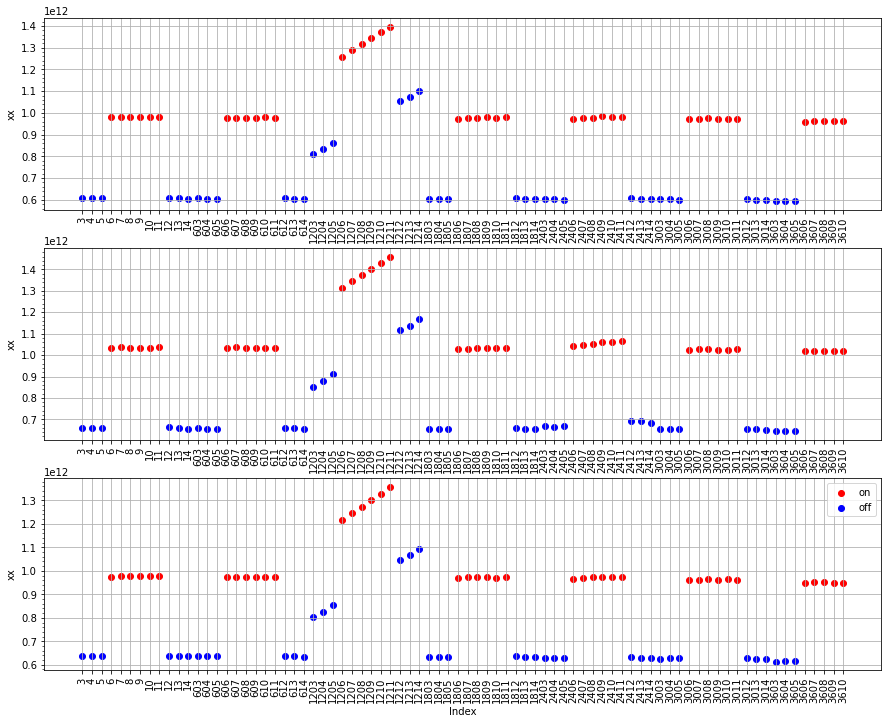

In [ ]:
%matplotlib inline
p_cals = Fd._get_cal_power(Fd.inds_ton, Fd.inds_toff_bef, Fd.inds_toff_aft)

In [ ]:
p_cals_s = Fd._get_smoothed(p_cals)

0


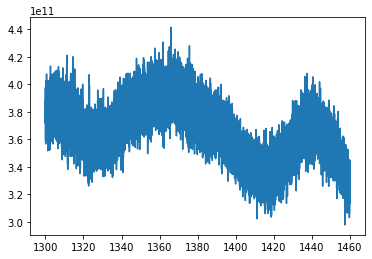

1


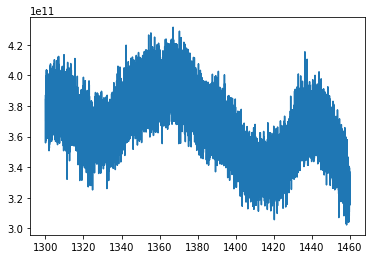

2


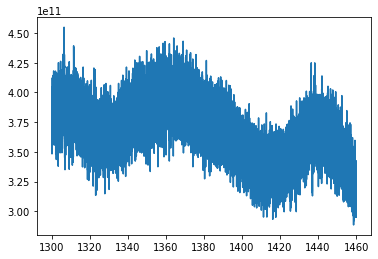

3


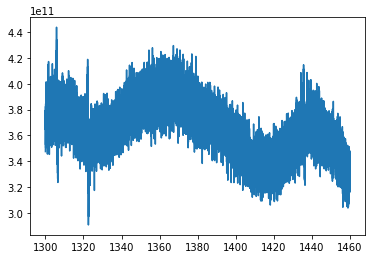

4


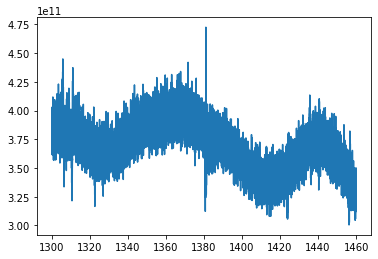

5


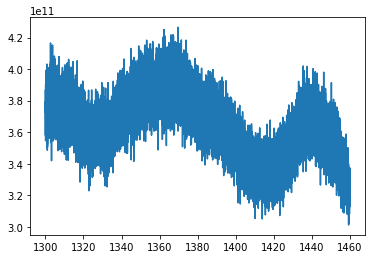

6


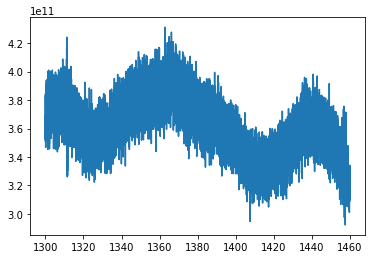

7


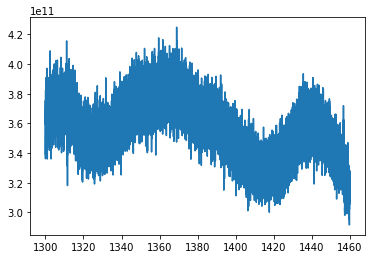

8


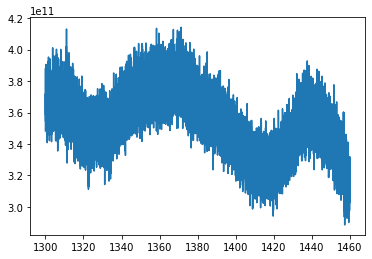

9


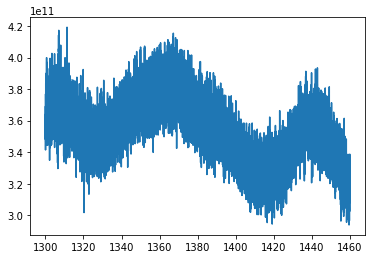

10


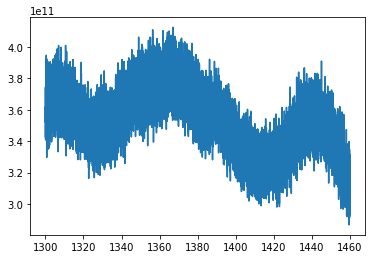

11


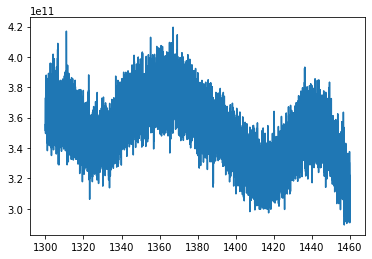

12


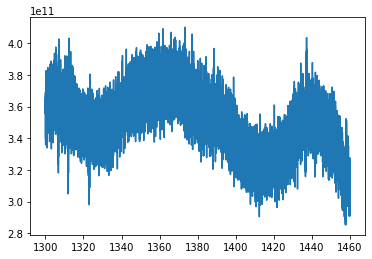

13


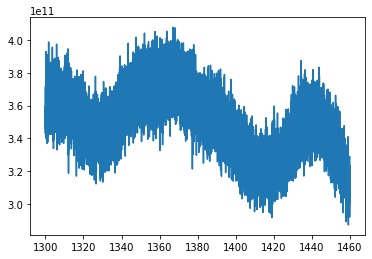

14


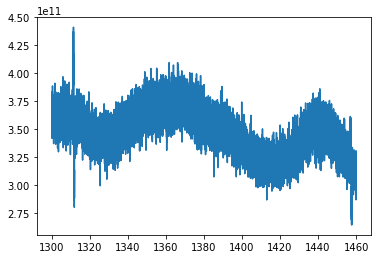

15


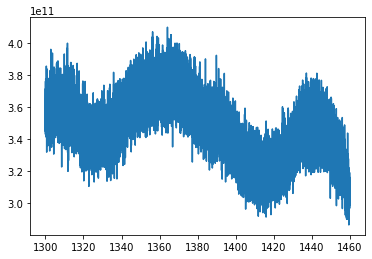

16


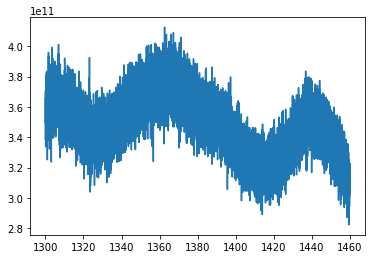

17


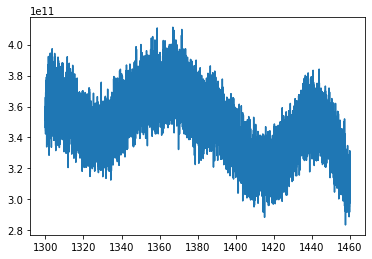

18


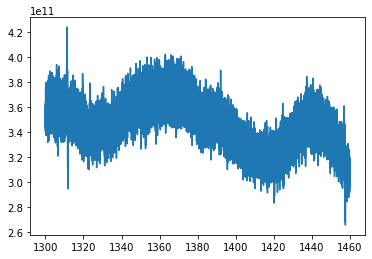

19


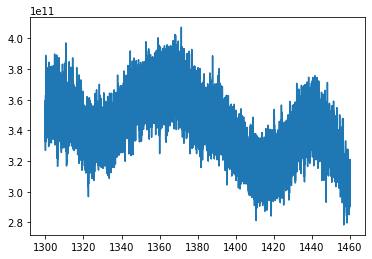

20


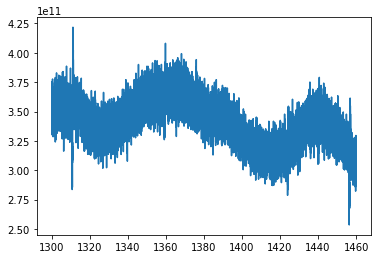

21


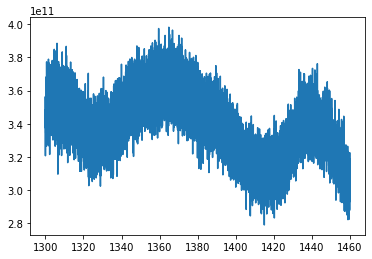

22


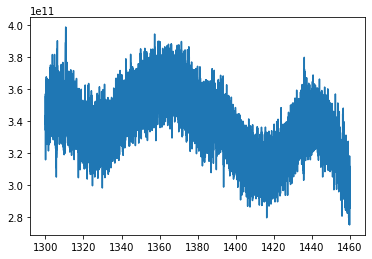

In [ ]:
%matplotlib inline

for i,p_cal in enumerate(p_cals[...,0]):
    plt.plot(Fd.freq_use, p_cal)
    print(i)
    plt.show()

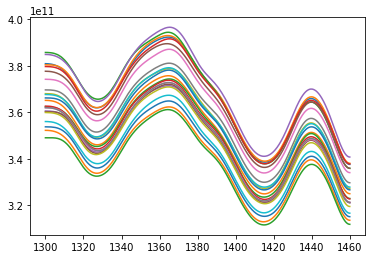

In [ ]:
%matplotlib inline

for i,p_cal in enumerate(p_cals_s[:,...,0]):
    plt.plot(Fd.freq_use, p_cal)
    #print(i)
    #plt.show()

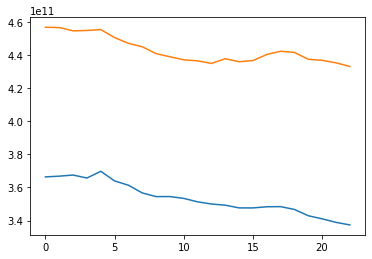

In [ ]:
plt.plot(np.mean(p_cals_s, axis=1))

In [ ]:
p_cal = p_cals[4, ...,0]

In [ ]:
from hifast.utils.misc import smooth1d

In [ ]:
from scipy import signal
from scipy import ndimage
from scipy import interpolate as inter

In [ ]:
5/(np.nanmax(Fd.freq_use) - np.nanmin(Fd.freq_use))*len(Fd.freq_use)

655.3912522651407

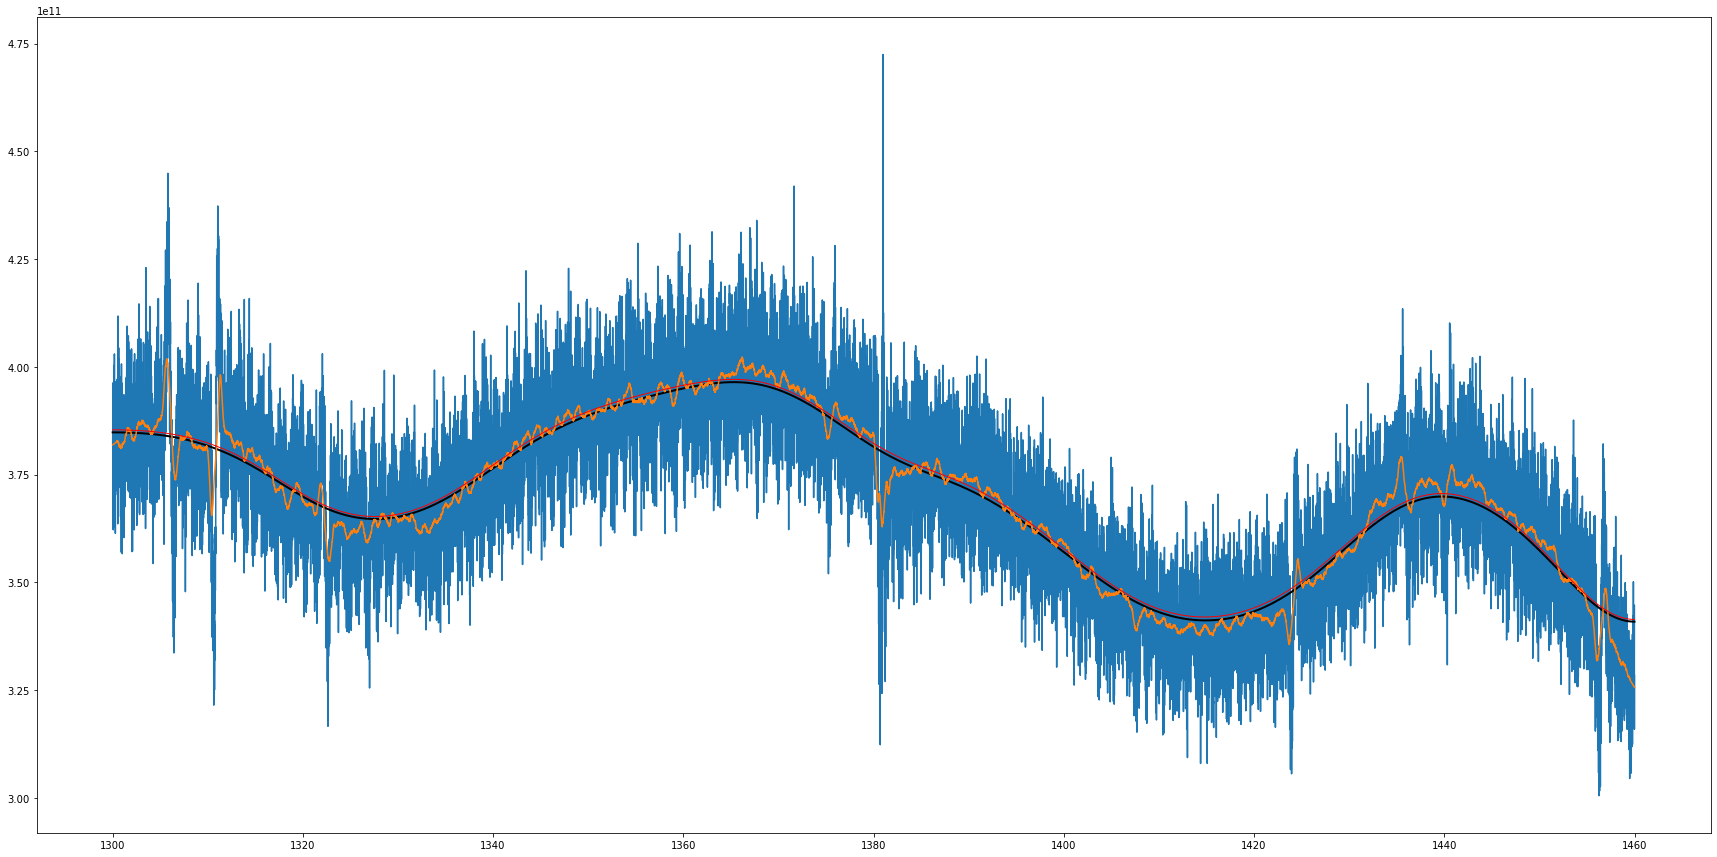

In [ ]:
plt.figure(figsize=(30,15))
plt.plot(Fd.freq_use, p_cal)
plt.plot(Fd.freq_use, smooth1d(p_cal, method='gaussian_fft', sigma=655),'k',lw=2)

#plt.plot(Fd.freq_use, smooth1d(signal.savgol_filter(p_cal,121,4), method='gaussian_fft', sigma=655),'r',lw=1)
#plt.plot(Fd.freq_use, ndimage.median_filter(p_cal,100))
plt.plot(Fd.freq_use, signal.savgol_filter(p_cal,121,1))
plt.plot(Fd.freq_use, smooth1d(ndimage.median_filter(p_cal,16), method='gaussian_fft', sigma=655),'r',lw=1)

#plt.ylim(3e11,5e11)

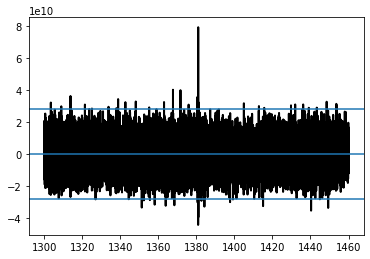

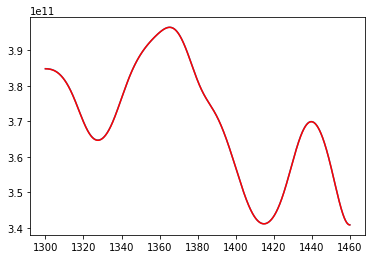

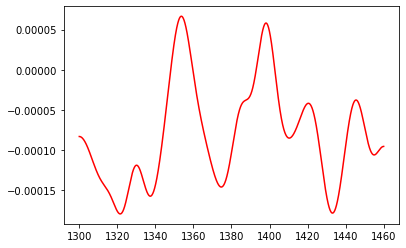

In [ ]:
#plt.figure(figsize=(30,15))
#plt.plot(Fd.freq_use, p_cal)
p_cal_s = smooth1d(p_cal, method='gaussian_fft', sigma=5)
diff = p_cal - p_cal_s

plt.plot(Fd.freq_use, diff,'k',lw=2)
lt, me, gt = np.percentile(diff, [16,50,84])
range_use = [me-3*(me-lt) , me+3*(gt-me)]

plt.axhline(y=range_use[0])
plt.axhline(y=range_use[1])
plt.axhline(y=me)
plt.show()

is_ = (diff > range_use[0]) &  (diff < range_use[1])
p_cal_2 = inter.interp1d(Fd.freq_use[is_], p_cal[is_],fill_value= "extrapolate")(Fd.freq_use)
p_cal_s_2 = smooth1d(p_cal_2, method='gaussian_fft', sigma=655)
p_cal_s_0 = smooth1d(p_cal, method='gaussian_fft', sigma=655)

plt.plot(Fd.freq_use, p_cal_s_0)
plt.plot(Fd.freq_use, p_cal_s_2,'r')
plt.show()
plt.plot(Fd.freq_use, (p_cal_s_2-p_cal_s_0)/p_cal_s_0,'r')